In [1]:
%pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [2]:
L = 40
T0, Tf = 5.0, 0.01
ANN_STEPS = 2000

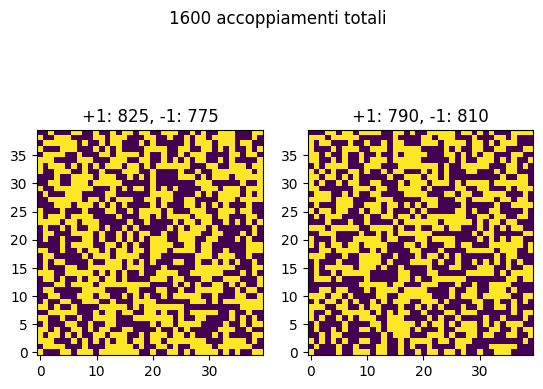

In [3]:
rng = np.random.default_rng(seed=75)
j_ver = rng.choice([-1,1], size=(L,L))
j_hor = rng.choice([-1,1], size=(L,L))
j_ver_up = 0
j_hor_up = 0
for i in range(L):
    for j in range(L):
        if j_ver[i,j] == 1:
            j_ver_up += 1

for i in range(L):
    for j in range(L):
        if j_hor[i,j] == 1:
            j_hor_up += 1

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(j_ver, origin="lower")
ax1.set_title(f"+1: {j_ver_up}, -1: {L**2 - j_ver_up}")
ax2.imshow(j_hor, origin="lower")
ax2.set_title(f"+1: {j_hor_up}, -1: {L**2 - j_hor_up}")
plt.suptitle(f"{L**2} accoppiamenti totali")
plt.show()

In [36]:
def greedy_mc(lattice, checkerboard, j_ver, j_hor, T=0.0):
    kb = 1.0
    for s in [checkerboard, ~checkerboard]:
        neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
        j_sum = np.roll(j_ver, shift=1, axis=1) + np.roll(j_ver, shift=-1, axis=1) + np.roll(j_hor, shift=1, axis=0) + np.roll(j_hor, shift=-1, axis=0)
        de = np.zeros_like(lattice)
        de_s = 2 * lattice[s] * neig_sum[s] * j_sum[s]
        accept = de_s <= 0
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

In [35]:
def energia(lattice, j_ver, j_hor):
    neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
    j_ver_sum = np.roll(j_ver, shift=1, axis=0) + np.roll(j_ver, shift=-1, axis=0) + np.roll(j_ver, shift=1, axis=1) + np.roll(j_ver, shift=-1, axis=1)
    j_hor_sum = np.roll(j_hor, shift=1, axis=0) + np.roll(j_hor, shift=-1, axis=0) + np.roll(j_hor, shift=1, axis=1) + np.roll(j_hor, shift=-1, axis=1)
    tot_en = -np.sum(lattice * j_ver_sum * j_hor_sum * neig_sum) / 2
    
    return tot_en

def magnetization(lattice):
    return np.abs(np.sum(lattice))

In [57]:
run = 10
energies = np.zeros(run)
magns = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        greedy_mc(lattice, checkerboard, j_ver, j_hor)
    
    energies[i] = energia(lattice, j_ver, j_hor)
    magns[i] = magnetization(lattice)

In [62]:
print(f"Energia per run per spin: {energies/L**2}")
print(f"Magnetizzazione per run per spin: {magns/L**2}")
print(f"Energia media: {np.mean(energies)}")
print(rf"Energia media per spin: ${np.mean(energies)/L**2} \pm {np.mean(energies)/np.sqrt(L**2)}$")
print(f"Energia minima: {np.min(energies)} e minima per spin: {np.min(energies)/L**2}")
print(f"Energia massima: {np.max(energies)} e massima per spin: {np.max(energies)/L**2}")
print(f"Magnetizzazione media: {np.mean(magns)}")
print(f"Magnetizzazione media per spin: {np.mean(magns)/L**2}")

Energia per run per spin: [ 0.1675  0.02    0.025  -0.0025  0.0975  0.0575  0.005   0.01    0.035
 -0.005 ]
Magnetizzazione per run per spin: [0.0525  0.00875 0.035   0.00875 0.0225  0.01375 0.01375 0.0325  0.025
 0.04   ]
Energia media: 65.6
Energia media per spin: $0.040999999999999995 \pm 1.64$
Energia minima: -8.0 e minima per spin: -0.005
Energia massima: 268.0 e massima per spin: 0.1675
Magnetizzazione media: 40.4
Magnetizzazione media per spin: 0.025249999999999998


In [40]:
def metropolis(lattice, j_hor, j_ver, even_mask, T=0.5):
    kb = 1.0
    for s in [even_mask, ~even_mask]:
        neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
        j_sum = np.roll(j_ver, shift=1, axis=1) + np.roll(j_ver, shift=-1, axis=1) + np.roll(j_hor, shift=1, axis=0) + np.roll(j_hor, shift=-1, axis=0)
        de = np.zeros_like(lattice)
        de_s = 2 * lattice[s] * neig_sum[s] * j_sum[s]
        prob = np.exp(-de_s/(kb*T))
        accept = (de_s <= 0) | (rng.random(de_s.shape) < prob)
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

In [60]:
run = 10
energies_metro = np.zeros(run)
magns_metro = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        metropolis(lattice, j_hor, j_ver, checkerboard)
    
    energies_metro[i] = energia(lattice, j_ver, j_hor)
    magns_metro[i] = magnetization(lattice)

In [63]:
print(f"Energia per run per spin: {energies_metro/L**2}")
print(f"Magnetizzazione per run per spin: {magns_metro/L**2}")
print(f"Energia media: {np.mean(energies_metro)}")
print(rf"Energia media per spin: ${np.mean(energies_metro)/L**2} \pm {np.mean(energies_metro)/np.sqrt(L**2)}$")
print(f"Energia minima: {np.min(energies_metro)} e minima per spin: {np.min(energies_metro)/L**2}")
print(f"Energia massima: {np.max(energies_metro)} e massima per spin: {np.max(energies_metro)/L**2}")
print(f"Magnetizzazione media: {np.mean(magns_metro)}")
print(f"Magnetizzazione media per spin: {np.mean(magns_metro)/L**2}")

Energia per run per spin: [-0.0125 -0.0425  0.0075 -0.05    0.08   -0.005  -0.095   0.0125  0.1075
 -0.1775]
Magnetizzazione per run per spin: [0.0075  0.05625 0.0575  0.05125 0.0525  0.      0.00625 0.0075  0.00625
 0.02125]
Energia media: -28.0
Energia media per spin: $-0.0175 \pm -0.7$
Energia minima: -284.0 e minima per spin: -0.1775
Energia massima: 172.0 e massima per spin: 0.1075
Magnetizzazione media: 42.6
Magnetizzazione media per spin: 0.026625


||Energia max|Energia min|Energia media|Energia media per spin|Magnetizzazione media|Magnetizzazione media per spin|
|---|---|---|---|---|---|---|
|Greedy|268|-8|65.6|0.0005|40.4|0.025|
|Metropolis|172|-284|-28|-0.0175|42.6|0.027|

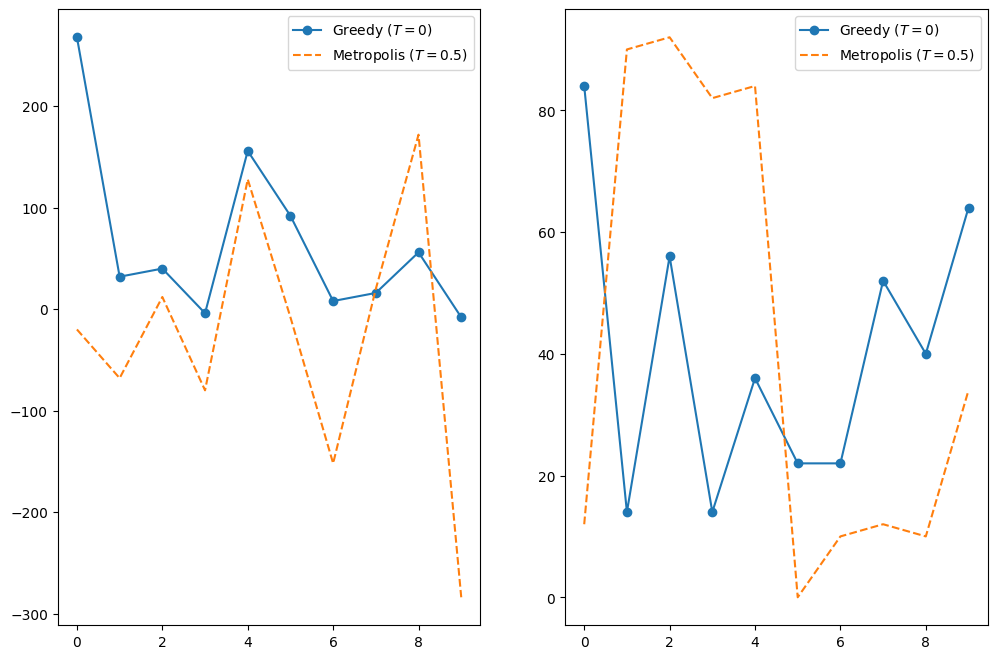

In [64]:
fig, (en, mag) = plt.subplots(1, 2, figsize=[12,8])
en.plot(energies, "-o", label=r"Greedy $(T=0)$")
en.plot(energies_metro, "--", label=r"Metropolis $(T=0.5)$")
en.legend()
mag.plot(magns, "-o", label=r"Greedy $(T=0)$")
mag.plot(magns_metro, "--", label=r"Metropolis $(T=0.5)$")
mag.legend()
plt.show()